In [1]:
import pandas as pd
df = pd.read_csv("human_ai_collab_log.csv")
df.head()
#df.info()
#df.describe()

,interaction_id,task_type,timestamp,prompt_length,ai_response_length,edit_distance,acceptance,override,time_to_edit,ai_quality
0,1,reflective,1,120,150,30,1,0,60,4
1,2,technical,2,85,210,45,1,0,120,3
2,3,coding,3,40,180,10,1,0,35,5
3,4,argumentative,4,95,160,70,0,1,200,4
4,5,creative,5,60,220,25,1,0,90,4


2) Feature Engineering(Transform raw data into meaningful input)

In [2]:
df['acceptance_rate'] = df['acceptance'].rolling(window=10).mean()
df['edit_intensity'] = df['edit_distance']/df['ai_response_length']
df['efficiency'] = df['ai_response_length'] / df['time_to_edit']
df['ai_quality_norm'] = df['ai_quality'] / 5 #normalization
df['trust_score'] = (df['acceptance'] * (1 - df['edit_intensity'])) #less edit= more perfect
df['calibration_gap'] = abs(df['ai_quality_norm'] - df['acceptance']) #adjusting/correcting frequency

3) Time Series Analysis(Trust score over time)

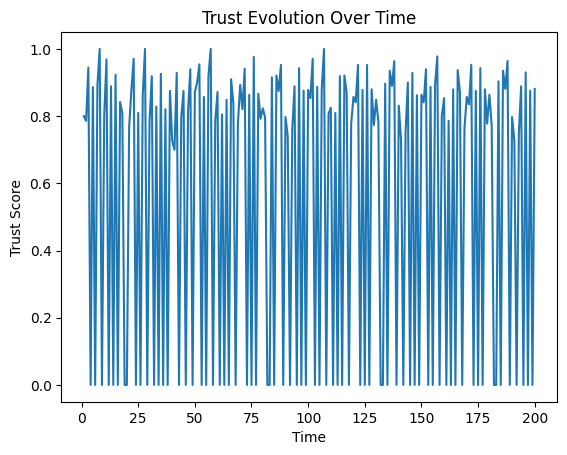

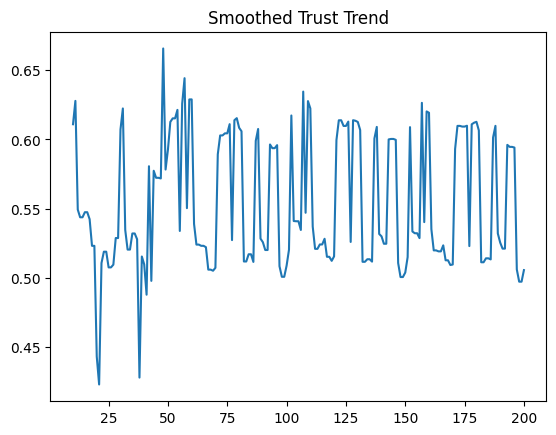

In [3]:
import matplotlib.pyplot as plt

plt.plot(df['timestamp'], df['trust_score'])
plt.xlabel("Time")
plt.ylabel("Trust Score")
plt.title("Trust Evolution Over Time")
plt.show()

df['rolling_trust'] = df['trust_score'].rolling(window=10).mean()
plt.plot(df['timestamp'], df['rolling_trust'])
plt.title("Smoothed Trust Trend")
plt.show()

3) Behaviour Classification

In [4]:
def classify(row):
    if row['ai_quality'] <= 2 and row['acceptance'] == 1:
        return "Over-reliant"
    elif row['ai_quality'] >= 4 and row['acceptance'] == 0:
        return "Under-utilizing"
    else:
        return "Well-calibrated"

df['behavior'] = df.apply(classify, axis=1)

df['behavior'].value_counts() #check distribution

behavior
Well-calibrated    162
Under-utilizing     38
Name: count, dtype: int64